In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
X_secom = np.load('../data/processed/X_secom.npy')
y_secom = np.load('../data/processed/y_secom.npy')
X_steel = pd.read_csv('../data/processed/X_steel.csv')
y_steel = pd.read_csv('../data/processed/y_steel.csv').squeeze()

# Train/Test Split
X_secom_train, X_secom_test, y_secom_train, y_secom_test = train_test_split(
    X_secom, y_secom, test_size=0.2, random_state=42, stratify=y_secom
)
X_steel_train, X_steel_test, y_steel_train, y_steel_test = train_test_split(
    X_steel, y_steel, test_size=0.2, random_state=42
)

print("Data loaded!")
print(f"SECOM Train: {X_secom_train.shape}, Test: {X_secom_test.shape}")
print(f"Steel Train: {X_steel_train.shape}, Test: {X_steel_test.shape}")

Data loaded!
SECOM Train: (2340, 100), Test: (586, 100)
Steel Train: (28028, 15), Test: (7008, 15)


In [2]:
# ===== SECOM Classification Models =====
models_secom = {
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Training SECOM models...")
secom_results = {}
for name, model in models_secom.items():
    model.fit(X_secom_train, y_secom_train)
    y_pred = model.predict(X_secom_test)
    cv_scores = cross_val_score(model, X_secom, y_secom, cv=5, scoring='f1')
    secom_results[name] = {
        'model': model, 'y_pred': y_pred,
        'cv_f1': cv_scores.mean(), 'cv_std': cv_scores.std()
    }
    print(f"  {name} - F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# ===== Steel Energy Regression Models =====
models_steel = {
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\nTraining Steel Energy models...")
steel_results = {}
for name, model in models_steel.items():
    model.fit(X_steel_train, y_steel_train)
    y_pred = model.predict(X_steel_test)
    r2 = r2_score(y_steel_test, y_pred)
    mae = mean_absolute_error(y_steel_test, y_pred)
    steel_results[name] = {
        'model': model, 'y_pred': y_pred, 'r2': r2, 'mae': mae
    }
    print(f"  {name} - R2: {r2:.3f}, MAE: {mae:.3f}")

Training SECOM models...
  XGBoost - F1: 0.728 (+/- 0.298)
  LightGBM - F1: 0.932 (+/- 0.095)
  Random Forest - F1: 0.946 (+/- 0.083)

Training Steel Energy models...
  XGBoost - R2: 0.998, MAE: 0.735
  LightGBM - R2: 0.998, MAE: 0.797
  Random Forest - R2: 0.997, MAE: 0.677


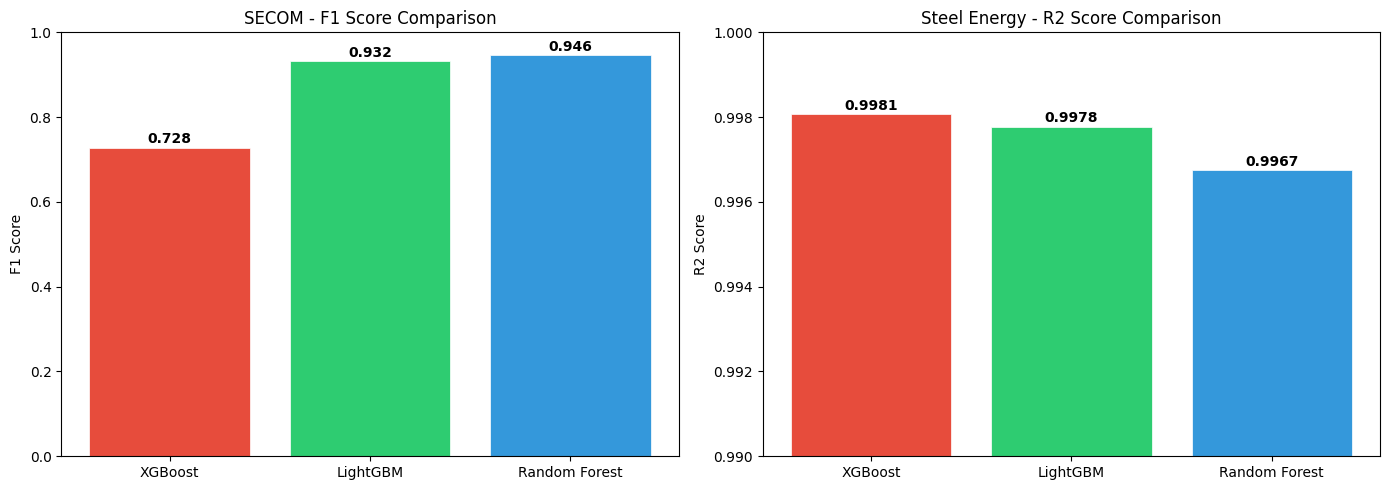

Chart saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SECOM F1 Score comparison
names = list(secom_results.keys())
f1_scores = [secom_results[n]['cv_f1'] for n in names]
colors = ['#e74c3c', '#2ecc71', '#3498db']

axes[0].bar(names, f1_scores, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('SECOM - F1 Score Comparison')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Steel R2 Score comparison
r2_scores = [steel_results[n]['r2'] for n in names]
axes[1].bar(names, r2_scores, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Steel Energy - R2 Score Comparison')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0.99, 1.0)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")



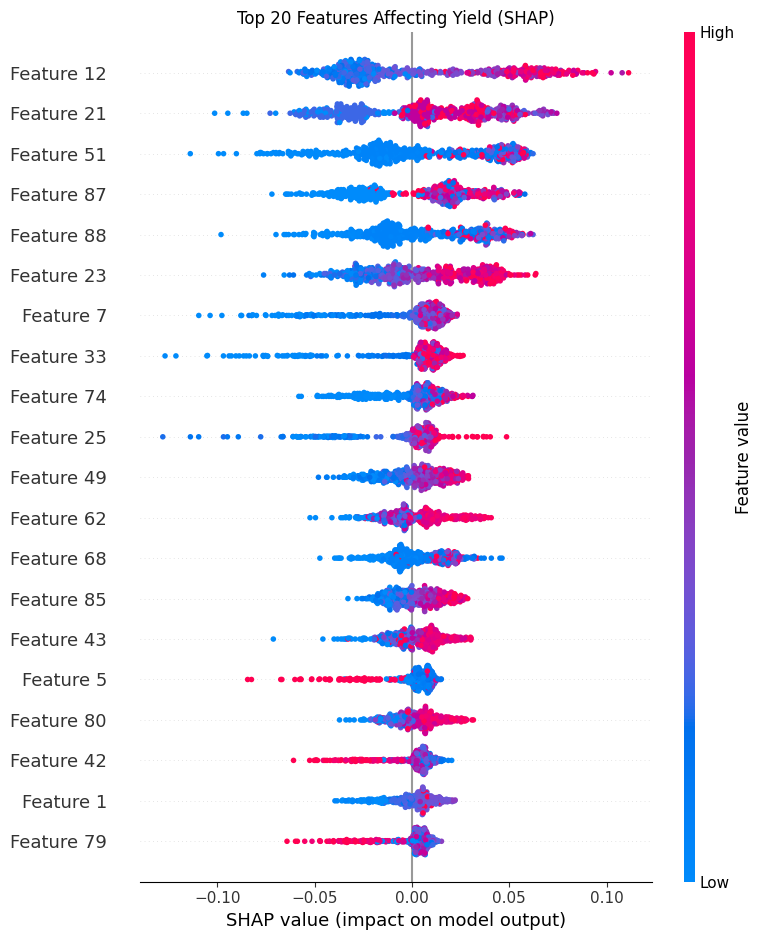

SHAP chart saved!


In [5]:
import shap

best_secom_model = secom_results['Random Forest']['model']

explainer = shap.TreeExplainer(best_secom_model)
shap_values = explainer.shap_values(X_secom_test)

# shap_values is a list for classification - take index 1 (Fail class)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[1],
    X_secom_test,
    max_display=20,
    show=False
)
plt.title('Top 20 Features Affecting Yield (SHAP)')
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP chart saved!")

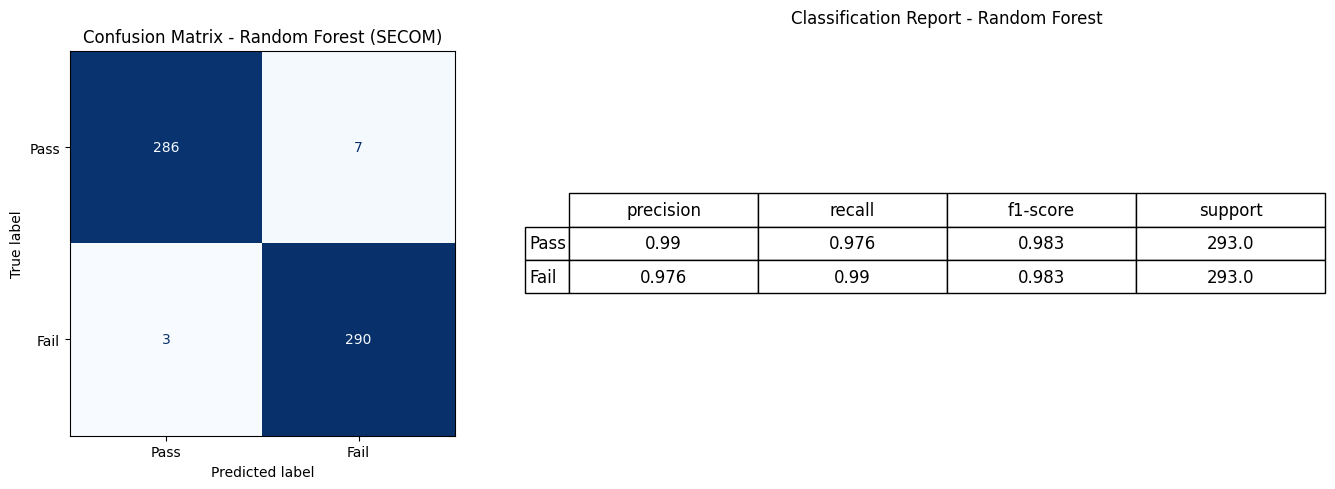

Confusion matrix saved!


In [8]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

best_model = secom_results['Random Forest']['model']
y_pred = secom_results['Random Forest']['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_secom_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix - Random Forest (SECOM)')

report = classification_report(y_secom_test, y_pred, target_names=['Pass', 'Fail'], output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])
axes[1].axis('off')
table = axes[1].table(
    cellText=report_df.values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[1].set_title('Classification Report - Random Forest', pad=20)

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

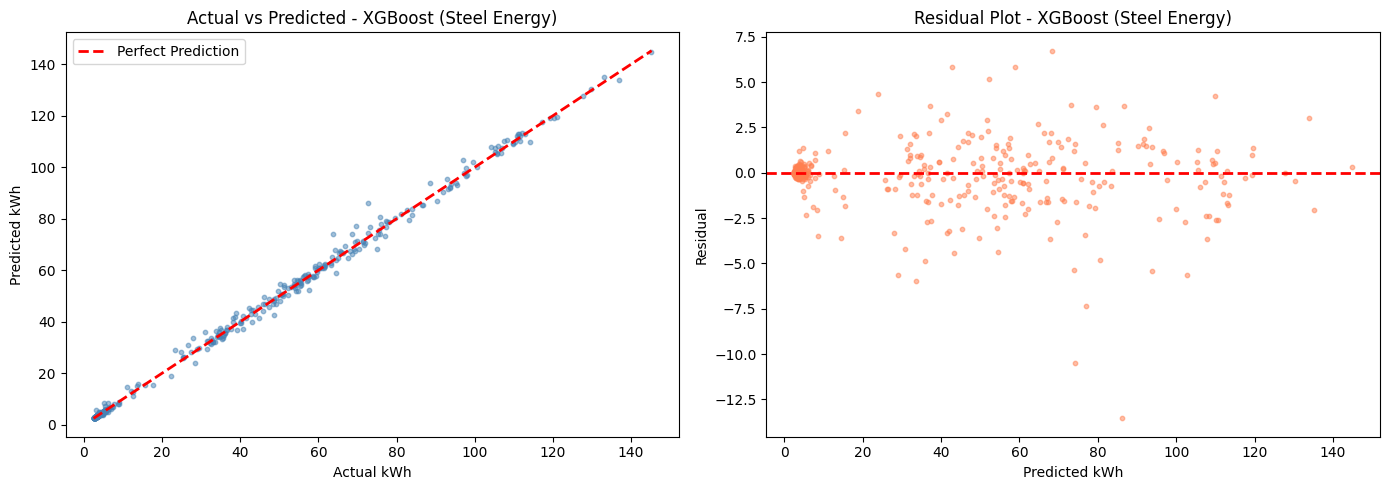

Plot saved!


In [9]:
# Actual vs Predicted - Steel Energy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_steel = steel_results['XGBoost']
y_pred_steel = best_steel['y_pred']

# Scatter plot
axes[0].scatter(y_steel_test[:500], y_pred_steel[:500], 
                alpha=0.5, color='steelblue', s=10)
axes[0].plot([y_steel_test.min(), y_steel_test.max()], 
             [y_steel_test.min(), y_steel_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual kWh')
axes[0].set_ylabel('Predicted kWh')
axes[0].set_title('Actual vs Predicted - XGBoost (Steel Energy)')
axes[0].legend()

# Residual plot
residuals = y_steel_test - y_pred_steel
axes[1].scatter(y_pred_steel[:500], residuals[:500], 
                alpha=0.5, color='coral', s=10)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted kWh')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot - XGBoost (Steel Energy)')

plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [10]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_secom, y_secom, cv=3, scoring='f1').mean()
    return score

print("Running Optuna hyperparameter tuning...")
print("This will take 2-3 minutes...")

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=30)

print(f"\nBest F1 Score: {study.best_value:.3f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-03-15 03:33:25,124] A new study created in memory with name: no-name-6fa9a71f-b7dd-4b9f-af9f-0c99dca9a403


Running Optuna hyperparameter tuning...
This will take 2-3 minutes...

Best F1 Score: 0.914
Best Parameters: {'n_estimators': 234, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}


In [11]:
# Tuned model train করো
best_params = study.best_params
tuned_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
tuned_model.fit(X_secom_train, y_secom_train)
y_pred_tuned = tuned_model.predict(X_secom_test)

# Compare default vs tuned
print("=== Model Comparison ===")
print(f"Default Random Forest F1 : {secom_results['Random Forest']['cv_f1']:.3f}")
print(f"Tuned Random Forest F1   : {study.best_value:.3f}")
print(f"\nTuned Classification Report:")
print(classification_report(y_secom_test, y_pred_tuned, target_names=['Pass', 'Fail']))

# Save tuned model
import pickle
with open('../data/processed/tuned_secom_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)

with open('../data/processed/best_steel_model.pkl', 'wb') as f:
    pickle.dump(steel_results['XGBoost']['model'], f)

print("Models saved!")

=== Model Comparison ===
Default Random Forest F1 : 0.946
Tuned Random Forest F1   : 0.914

Tuned Classification Report:
              precision    recall  f1-score   support

        Pass       0.99      0.98      0.98       293
        Fail       0.98      0.99      0.98       293

    accuracy                           0.98       586
   macro avg       0.98      0.98      0.98       586
weighted avg       0.98      0.98      0.98       586

Models saved!
